## NUMBER PLATE DETECTION

In [8]:
!python -m pip install easyocr

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [8]:
# detection[0]: The bounding box coordinates (where the text is located).
# detection[1]: The actual text string found inside that box.
# detection[2]: The confidence score (how sure the AI is about the text).

import easyocr

reader=easyocr.Reader(['en']) # Load English Model
result= reader.readtext(r"C:\Users\vv\OneDrive\Desktop\IMG_20240823_211857_281.jpg")
for detection in result:
    print(detection[1])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\vv\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


THE BEST
PREPARATION FOR
TOMORROW IS
DOING YOUR BEST
TODAY.


In [1]:
import numpy as np

In [3]:
pip install imutils

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25854 sha256=f201aa07edca2efc4f674ea9812470bf15142d4173750a0323de5b10b8e2e77c
  Stored in directory: c:\users\vv\appdata\local\pip\cache\wheels\c2\02\32\f3617a9f68bcc67eda3ebeb4514eba18f62e81ff439428109d
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: C:\Users\vv\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [9]:
import imutils

In [10]:
import easyocr

In [16]:
import matplotlib.pyplot as plt

#### 1. READ IN IMAGE, GRAYSCALE AND BLUR

In [18]:
import cv2

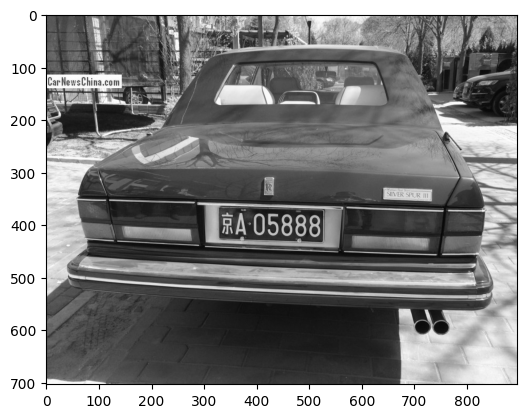

In [19]:
img=cv2.imread(r"C:\Users\vv\OneDrive\Desktop\PYTHON\rolls-royce-mulliner-china-8.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

#### APPLY FILTER AND FIND EDGES FOR LOCALIZATION

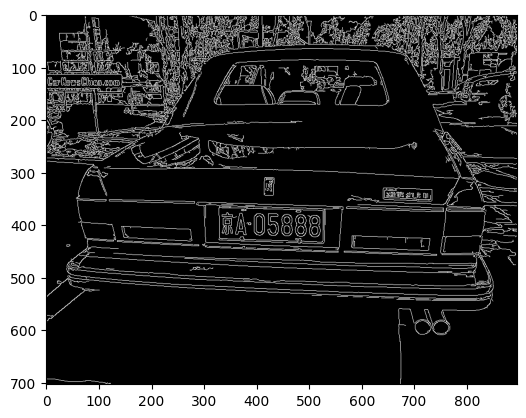

In [21]:
bfilter= cv2.bilateralFilter(gray,4,7,7)   # Noise Reduction
edged= cv2.Canny(bfilter,30,300) # edge detection
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

#### 3. FIND CONTOURS AND APPLY MASK AND MORPHOLOGY

In [23]:
# Create a kernel (size can be adjusted, e.g., 3x3 or 5x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# Apply closing to connect disconnected edges
closed = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

In [24]:
keypoints=cv2.findContours(closed.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours=imutils.grab_contours(keypoints)
contours=sorted(contours, key=cv2.contourArea, reverse=True)[:10]

In [25]:
location=None
for contour in contours:
    peri = cv2.arcLength(contour, True)
    approx=cv2.approxPolyDP(contour,0.08* peri, True)
   
    if len(approx)==4:
        location=approx
        break

In [26]:
location

array([[[328, 369]],

       [[525, 373]],

       [[526, 430]],

       [[331, 426]]], dtype=int32)

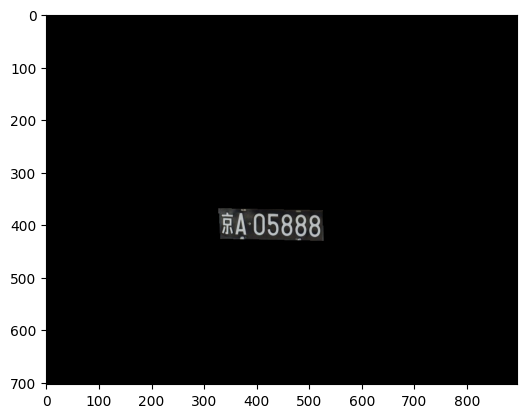

In [27]:
import cv2
import numpy as np

# Assuming 'img' is your original color image and 'gray' is the grayscale version
mask = np.zeros(gray.shape, np.uint8)

# Fill the contour defined by the location array with white (255)
new_image=cv2.drawContours(mask, [location], 0, 255, -1)


# Apply the mask to the original image to extract the number plate
# cv2.bitwise_and(): This OpenCV function compares every single pixel of two images using a logical AND operation.
# img, img: You pass the original image twice because the function requires two input sources to compare. An pixel ANDed with itself remains unchanged.
# mask=mask: This is the filtering layer. A mask is a black-and-white image where the background is black (pixel value 0) and the 
# license plate region is white (pixel value 255).

new_image = cv2.bitwise_and(img, img, mask=mask)


plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))


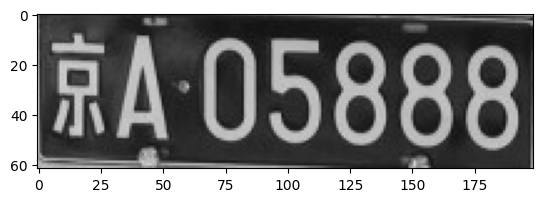

In [28]:
# mask==255: Creates a boolean array (True/False) identifying where the pixel value is exactly 255 (pure white).
# np.where(): Finds the indices of the True values.
# (x, y): Returns two separate NumPy arrays. x stores the row indices(vertical positions),and y stores the column indices(horizontal positions) of 
# all white pixels.


(x,y)=np.where(mask==255)
(topx, topy) = (np.min(x), np.min(y))
(bottomx, bottomy)= (np.max(x), np.max(y))
cropped_image= gray[topx:bottomx+1, topy:bottomy+1]

plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

# np.min(x) and np.min(y): Finds the topmost row (topx) and the leftmost column (topy) where the object starts.
# np.max(x) and np.max(y): Finds the bottommost row (bottomx) and the rightmost column (bottomy) where the object ends.
# Together, these four coordinates define the smallest possible rectangle (bounding box) that completely encloses the white object.

In [29]:
reader=easyocr.Reader(['en'])
result=reader.readtext(cropped_image)
result

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\vv\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[([[0, 0], [199, 0], [199, 62], [0, 62]],
  'RA 05888',
  np.float64(0.6076300970254351))]

#### 5.RENDER RESULT

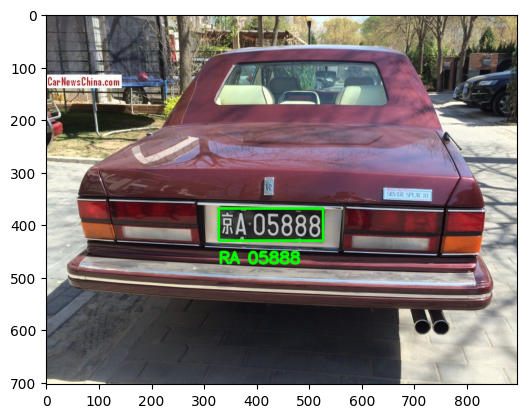

In [31]:
text=result[0][-2]
font=cv2.FONT_HERSHEY_SIMPLEX
res=cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+ 100), fontFace=font, fontScale=1, color=(0,255,0), thickness=4, lineType=cv2.LINE_AA)
res=cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0), 3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))


# This code snippet uses the OpenCV and Matplotlib libraries in Python to draw a green bounding box around a detected object in an image and 
# overlay extracted text near it.Here is the exact step-by-step breakdown of what the code is doing:
# text = result[0][-2]: Retrieves the specific text to be displayed from a nested array called result and stores it in the text variable.
# font = cv2.FONT_HERSHEY_SIMPLEX: Sets the font style for the text to a standard, plain sans-serif font provided by OpenCV.
# res = cv2.putText(...): Draws the text onto the image:
# org: Sets the starting coordinate for the text. It positions the text just below the detected box (y-coordinate of approx[1][0][1] + 100).
# fontScale, color, thickness: Scales the text size to 1, makes it bright green (0, 255, 0), and sets the line thickness to 4 pixels.
# lineType=cv2.LINE_AA: Uses anti-aliasing to make the text edges appear smooth.
# res = cv2.rectangle(...): Draws the actual bounding box directly on the image (img)
# :tuple(approx[0][0]) to tuple(approx[2][0]): Defines the top-left and bottom-right corners of the box based on the approx coordinate array.
# (0,255,0), 3: Sets the box outline to bright green with a thickness of 3 pixels.
# plt.imshow(...): Displays the final processed image using Matplotlib:
# cv2.cvtColor(res, cv2.COLOR_BGR2RGB): Converts the image color format from OpenCV’s default BGR to Matplotlib's standard RGB so the colors display correctly on your screen.